#  Modèles non supervisés

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Style global pour rapport
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})

COL_NORMAL  = '#2196F3'
COL_ANOMALY = '#E53935'
COL_SEUIL   = '#FF6F00'

print('Imports OK')

Imports OK


## 1. Chargement et préparation

In [2]:
path = r"C:\Users\Pc\Desktop\new\features_comptes.xlsx"
df   = pd.read_excel(path)
print(f"Dataset : {df.shape[0]} comptes | {df.shape[1]} colonnes")

cols_exclude = ['compte', 'lieu_principal']
X = df.drop(columns=cols_exclude, errors='ignore')
X = X.select_dtypes(include=np.number)
X = X.loc[:, X.nunique() > 1]
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
print(f"Features disponibles : {X.shape[1]}")

Dataset : 2839 comptes | 27 colonnes
Features disponibles : 25


In [3]:
# Log-transform des features asymétriques
cols_log = [col for col in X.columns if abs(X[col].skew()) > 1]
for col in cols_log:
    X[col] = np.log1p(X[col])
print(f"Features log-transformées : {len(cols_log)}")
print(f"Features : {cols_log}")

Features log-transformées : 22
Features : ['nb_transactions', 'total_montant', 'montant_moyen', 'montant_median', 'montant_std', 'montant_min', 'montant_max', 'duree_activite_jours', 'ratio_max_moyen', 'nb_transactions_mois', 'nb_lieux_differents', 'pct_lieu_principal', 'temps_moyen_entre_tx_min', 'temps_median_entre_tx_min', 'temps_min_entre_tx_min', 'temps_std_entre_tx_min', 'montants_croissants_consecutifs', 'ratio_montant_max_min', 'velocite_maximale_km_h', 'nb_tpe_moins_100', 'ratio_tpe_moins_100', 'tx_par_jour']


In [4]:
VT_THRESHOLDS  = [0.1, 0.2, 0.5]
CORR_THRESHOLD = 0.85

def apply_vt_and_corr_filter(X, vt_threshold, corr_threshold=0.85, verbose=False):
    selector    = VarianceThreshold(threshold=vt_threshold)
    X_vt        = selector.fit_transform(X)
    cols_vt     = X.columns[selector.get_support()].tolist()
    X_vt_df     = pd.DataFrame(X_vt, columns=cols_vt)
    corr_matrix = X_vt_df.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop     = [col for col in upper.columns if any(upper[col] > corr_threshold)]
    cols_final  = [c for c in cols_vt if c not in to_drop]
    X_filtered  = X_vt_df[cols_final].values
    if verbose:
        print(f"  VT={vt_threshold} -> {len(cols_vt)} features | corr -> {len(to_drop)} supprimees | final : {len(cols_final)}")
    return X_filtered, cols_final

apply_vt_and_corr_filter(X, 0.2, CORR_THRESHOLD, verbose=True)
print('Fonction prete')

  VT=0.2 -> 16 features | corr -> 6 supprimees | final : 10
Fonction prete


## 2. K-Means (avec PCA dans le grid search)
### Justification : K-Means basé sur distances — sensible à la malédiction de la dimensionnalité

In [12]:
print('=' * 65)
print('K-MEANS — RECHERCHE DES MEILLEURS PARAMETRES (avec PCA)')
print('=' * 65)

pca_components_km = [2, 3, 5, 8, None]
k_values          = [2, 3, 4, 5]

print(f"\n{'VT':>4} | {'PCA':>4} | {'k':>3} | {'Feats':>5} | {'Var%':>6} | {'Silhouette':>10} | {'DB':>8} | {'CH':>8}")
print('-' * 65)

resultats_km = []
for vt in VT_THRESHOLDS:
    X_filtered, cols_final = apply_vt_and_corr_filter(X, vt, CORR_THRESHOLD)
    X_scaled = StandardScaler().fit_transform(X_filtered)

    for n_pca in pca_components_km:
        if n_pca is not None:
            n_pca_safe = min(n_pca, X_scaled.shape[1] - 1)
            if n_pca_safe < 2:
                continue
            pca       = PCA(n_components=n_pca_safe, random_state=42)
            X_in      = pca.fit_transform(X_scaled)
            var       = pca.explained_variance_ratio_.sum()
            pca_label = str(n_pca_safe)
        else:
            X_in      = X_scaled.copy()
            var       = 1.0
            pca_label = 'Non'

        for k in k_values:
            km       = KMeans(n_clusters=k, random_state=42, n_init=20)
            clusters = km.fit_predict(X_in)
            if np.bincount(clusters).min() < 50:
                continue
            sil = silhouette_score(X_in, clusters)
            db  = davies_bouldin_score(X_in, clusters)
            ch  = calinski_harabasz_score(X_in, clusters)
            # On sauvegarde X_scaled pour la visualisation PCA 2D cohérente
            resultats_km.append((vt, n_pca_safe if n_pca else None, k,
                                  sil, db, ch, X_in, X_scaled,
                                  clusters, km, var, len(cols_final)))
            print(f"{vt:>4.1f} | {pca_label:>4} | {k:>3} | {len(cols_final):>5} | "
                  f"{var:>6.1%} | {sil:>10.4f} | {db:>8.4f} | {ch:>8.1f}")

best_km = max(resultats_km, key=lambda r: r[3])
vt_km, pca_km, k_km, sil_km, db_km, ch_km, X_in_km, X_scaled_km, \
    clusters_km, km_model, var_km, nfeat_km = best_km
pca_km_label = str(pca_km) if pca_km else 'Non'

print(f"\nMeilleure config K-Means : VT={vt_km}, PCA={pca_km_label}, k={k_km}, {nfeat_km} features")
print(f"  Silhouette={sil_km:.4f} | DB={db_km:.4f} | CH={ch_km:.1f} | Variance={var_km:.1%}")

K-MEANS — RECHERCHE DES MEILLEURS PARAMETRES (avec PCA)

  VT |  PCA |   k | Feats |   Var% | Silhouette |       DB |       CH
-----------------------------------------------------------------
 0.1 |    2 |   2 |    14 |  57.7% |     0.5307 |   0.6926 |   4865.7
 0.1 |    2 |   3 |    14 |  57.7% |     0.4056 |   0.9240 |   3796.2
 0.1 |    2 |   4 |    14 |  57.7% |     0.3651 |   0.9803 |   3382.5
 0.1 |    2 |   5 |    14 |  57.7% |     0.3864 |   0.9179 |   3526.0
 0.1 |    3 |   2 |    14 |  66.7% |     0.4680 |   0.8239 |   3426.6
 0.1 |    3 |   3 |    14 |  66.7% |     0.3274 |   1.1749 |   2432.7
 0.1 |    3 |   4 |    14 |  66.7% |     0.3655 |   1.0019 |   2323.6
 0.1 |    3 |   5 |    14 |  66.7% |     0.3359 |   0.9977 |   2193.9
 0.1 |    5 |   2 |    14 |  81.2% |     0.3911 |   1.0252 |   2313.7
 0.1 |    5 |   3 |    14 |  81.2% |     0.3996 |   0.9498 |   1552.0
 0.1 |    5 |   4 |    14 |  81.2% |     0.2601 |   1.2556 |   1355.3
 0.1 |    5 |   5 |    14 |  81.2% | 

Anomalies K-Means (P97) : 86


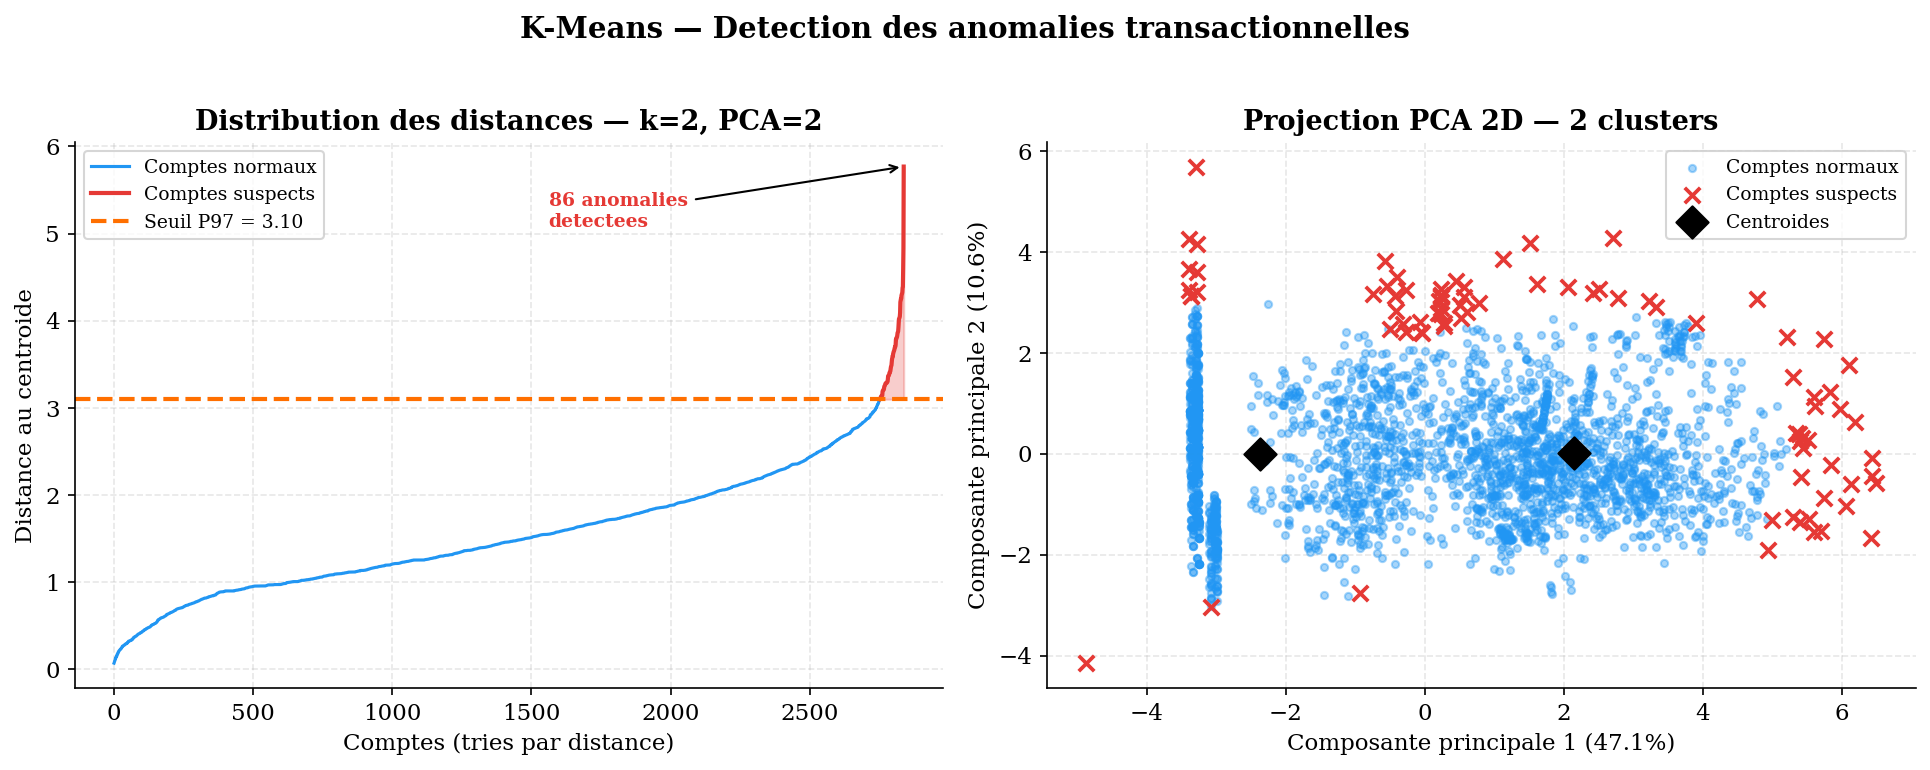

Figure sauvegardee : kmeans_rapport.png


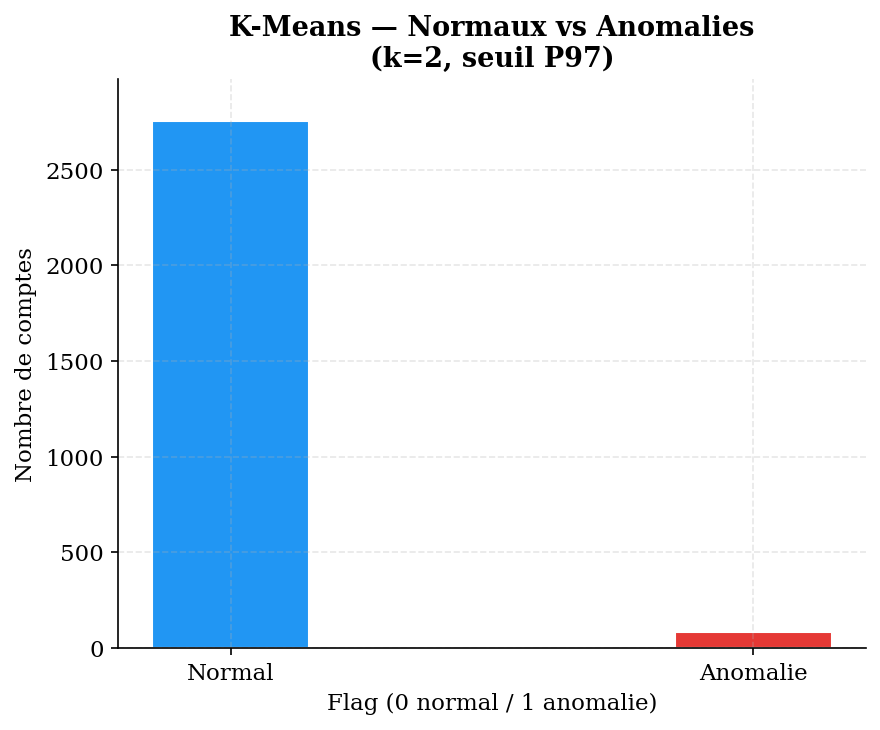

Figure sauvegardee : kmeans_barres_rapport.png


In [13]:
# Détection anomalies K-Means (seuil P97)
distances_km  = np.linalg.norm(X_in_km - km_model.cluster_centers_[clusters_km], axis=1)
threshold_km  = np.percentile(distances_km, 97)
df['cluster_km']  = clusters_km
df['distance_km'] = distances_km
df['kmeans_flag'] = (distances_km > threshold_km).astype(int)
nb_anomalies_km   = df['kmeans_flag'].sum()
print(f"Anomalies K-Means (P97) : {nb_anomalies_km}")

anomaly_mask_km = df['kmeans_flag'] == 1
normal_mask_km  = df['kmeans_flag'] == 0

# PCA 2D depuis X_scaled original (pas depuis X_in_km) pour éviter double réduction
pca_viz    = PCA(n_components=2, random_state=42)
X_2d_km    = pca_viz.fit_transform(X_scaled_km)
var_exp_km = pca_viz.explained_variance_ratio_

# Reconstruction des centroïdes dans l'espace original
if pca_km is not None:
    pca_best = PCA(n_components=pca_km, random_state=42)
    pca_best.fit(X_scaled_km)
    centroids_original = pca_best.inverse_transform(km_model.cluster_centers_)
else:
    centroids_original = km_model.cluster_centers_
centroids_2d = pca_viz.transform(centroids_original)

# ============================================================
# VISUALISATION K-MEANS
# Panneau gauche : distances triées
# Panneau droit  : scatter PCA 2D (uniquement K-Means)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means — Detection des anomalies transactionnelles',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
sorted_d  = np.sort(distances_km)
idx_seuil = np.searchsorted(sorted_d, threshold_km)
ax.plot(range(idx_seuil), sorted_d[:idx_seuil], color=COL_NORMAL, linewidth=1.5, label='Comptes normaux')
ax.plot(range(idx_seuil, len(sorted_d)), sorted_d[idx_seuil:], color=COL_ANOMALY, linewidth=2, label='Comptes suspects')
ax.axhline(threshold_km, color=COL_SEUIL, linestyle='--', linewidth=2, label=f'Seuil P97 = {threshold_km:.2f}')
ax.fill_between(range(idx_seuil, len(sorted_d)), sorted_d[idx_seuil:], threshold_km, alpha=0.25, color=COL_ANOMALY)
ax.set_xlabel('Comptes (tries par distance)')
ax.set_ylabel('Distance au centroide')
ax.set_title(f'Distribution des distances — k={k_km}, PCA={pca_km_label}')
ax.legend(fontsize=9)
ax.annotate(f'{nb_anomalies_km} anomalies\ndetectees',
            xy=(len(sorted_d)-1, sorted_d[-1]),
            xytext=(len(sorted_d)*0.55, sorted_d[-1]*0.88),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color=COL_ANOMALY, fontweight='bold')

ax = axes[1]
ax.scatter(X_2d_km[normal_mask_km, 0], X_2d_km[normal_mask_km, 1],
           alpha=0.4, s=12, color=COL_NORMAL, label='Comptes normaux', zorder=2)
ax.scatter(X_2d_km[anomaly_mask_km, 0], X_2d_km[anomaly_mask_km, 1],
           color=COL_ANOMALY, s=55, marker='x', linewidths=1.8, label='Comptes suspects', zorder=3)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           color='black', s=120, marker='D', zorder=4, label='Centroides')
ax.set_xlabel(f'Composante principale 1 ({var_exp_km[0]:.1%})')
ax.set_ylabel(f'Composante principale 2 ({var_exp_km[1]:.1%})')
ax.set_title(f'Projection PCA 2D — {k_km} clusters')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : kmeans_rapport.png')

# Diagramme barres K-Means
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Normal', 'Anomalie'],
       [normal_mask_km.sum(), anomaly_mask_km.sum()],
       color=[COL_NORMAL, COL_ANOMALY], edgecolor='white', width=0.3)
ax.set_xlabel('Flag (0 normal / 1 anomalie)')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'K-Means — Normaux vs Anomalies\n(k={k_km}, seuil P97)')
ax.set_ylim(0, normal_mask_km.sum() * 1.08)
plt.tight_layout()
plt.savefig('kmeans_barres_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : kmeans_barres_rapport.png')

BIRCH

In [14]:
# ============================================================
# BIRCH — Grid Search (sans PCA)
# Justification : BIRCH est un algorithme de clustering hiérarchique
# conçu pour les grands volumes de données, robuste aux grandes
# dimensions grâce à sa structure CFTree — PCA inutile
# ============================================================
from sklearn.cluster import Birch

print('=' * 65)
print('BIRCH — RECHERCHE DES MEILLEURS PARAMETRES (sans PCA)')
print('=' * 65)

threshold_values  = [0.3, 0.5, 0.7, 1.0]
branching_factors = [20, 50]
n_clusters_values = [2, 3, 4, 5]

print(f"\n{'VT':>4} | {'Thresh':>6} | {'Branch':>6} | {'n_clust':>7} | {'Feats':>5} | "
      f"{'Silhouette':>10} | {'DB':>8} | {'CH':>8}")
print('-' * 70)

resultats_birch = []
for vt in VT_THRESHOLDS:
    X_filtered, cols_final = apply_vt_and_corr_filter(X, vt, CORR_THRESHOLD)
    X_scaled = StandardScaler().fit_transform(X_filtered)

    for thresh in threshold_values:
        for branch in branching_factors:
            for n_clust in n_clusters_values:
                birch    = Birch(threshold=thresh, branching_factor=branch,
                                 n_clusters=n_clust)
                clusters = birch.fit_predict(X_scaled)

                # Vérifier que chaque cluster a au moins 50 comptes
                counts = np.bincount(clusters + clusters.min() * -1)
                if counts.min() < 50:
                    continue

                sil = silhouette_score(X_scaled, clusters)
                db  = davies_bouldin_score(X_scaled, clusters)
                ch  = calinski_harabasz_score(X_scaled, clusters)

                resultats_birch.append((vt, thresh, branch, n_clust,
                                         len(cols_final), sil, db, ch,
                                         X_scaled, clusters, birch))
                print(f"{vt:>4.1f} | {thresh:>6.1f} | {branch:>6} | {n_clust:>7} | "
                      f"{len(cols_final):>5} | {sil:>10.4f} | {db:>8.4f} | {ch:>8.1f}")

best_birch = max(resultats_birch, key=lambda r: r[5])
vt_birch, thresh_birch, branch_birch, nclust_birch, nfeat_birch, \
    sil_birch, db_birch, ch_birch, X_in_birch, clusters_birch, birch_model = best_birch

print(f"\nMeilleure config BIRCH : VT={vt_birch}, threshold={thresh_birch}, "
      f"branching_factor={branch_birch}, n_clusters={nclust_birch}")
print(f"  Silhouette={sil_birch:.4f} | DB={db_birch:.4f} | CH={ch_birch:.1f}")

BIRCH — RECHERCHE DES MEILLEURS PARAMETRES (sans PCA)

  VT | Thresh | Branch | n_clust | Feats | Silhouette |       DB |       CH
----------------------------------------------------------------------
 0.1 |    0.3 |     20 |       2 |    14 |     0.3234 |   1.2559 |   1584.1
 0.1 |    0.3 |     20 |       3 |    14 |     0.3359 |   1.1468 |   1055.6
 0.1 |    0.3 |     20 |       4 |    14 |     0.2116 |   1.5686 |    824.6
 0.1 |    0.3 |     20 |       5 |    14 |     0.2022 |   1.7886 |    678.0
 0.1 |    0.3 |     50 |       2 |    14 |     0.3240 |   1.2546 |   1587.7
 0.1 |    0.3 |     50 |       3 |    14 |     0.3364 |   1.1458 |   1057.8
 0.1 |    0.3 |     50 |       4 |    14 |     0.2109 |   1.6264 |    827.3
 0.1 |    0.3 |     50 |       5 |    14 |     0.2035 |   1.8153 |    680.2
 0.1 |    0.5 |     20 |       2 |    14 |     0.3234 |   1.2559 |   1584.1
 0.1 |    0.5 |     20 |       3 |    14 |     0.3360 |   1.1598 |   1061.1
 0.1 |    0.5 |     20 |       4 |    

Anomalies BIRCH (P97) : 86


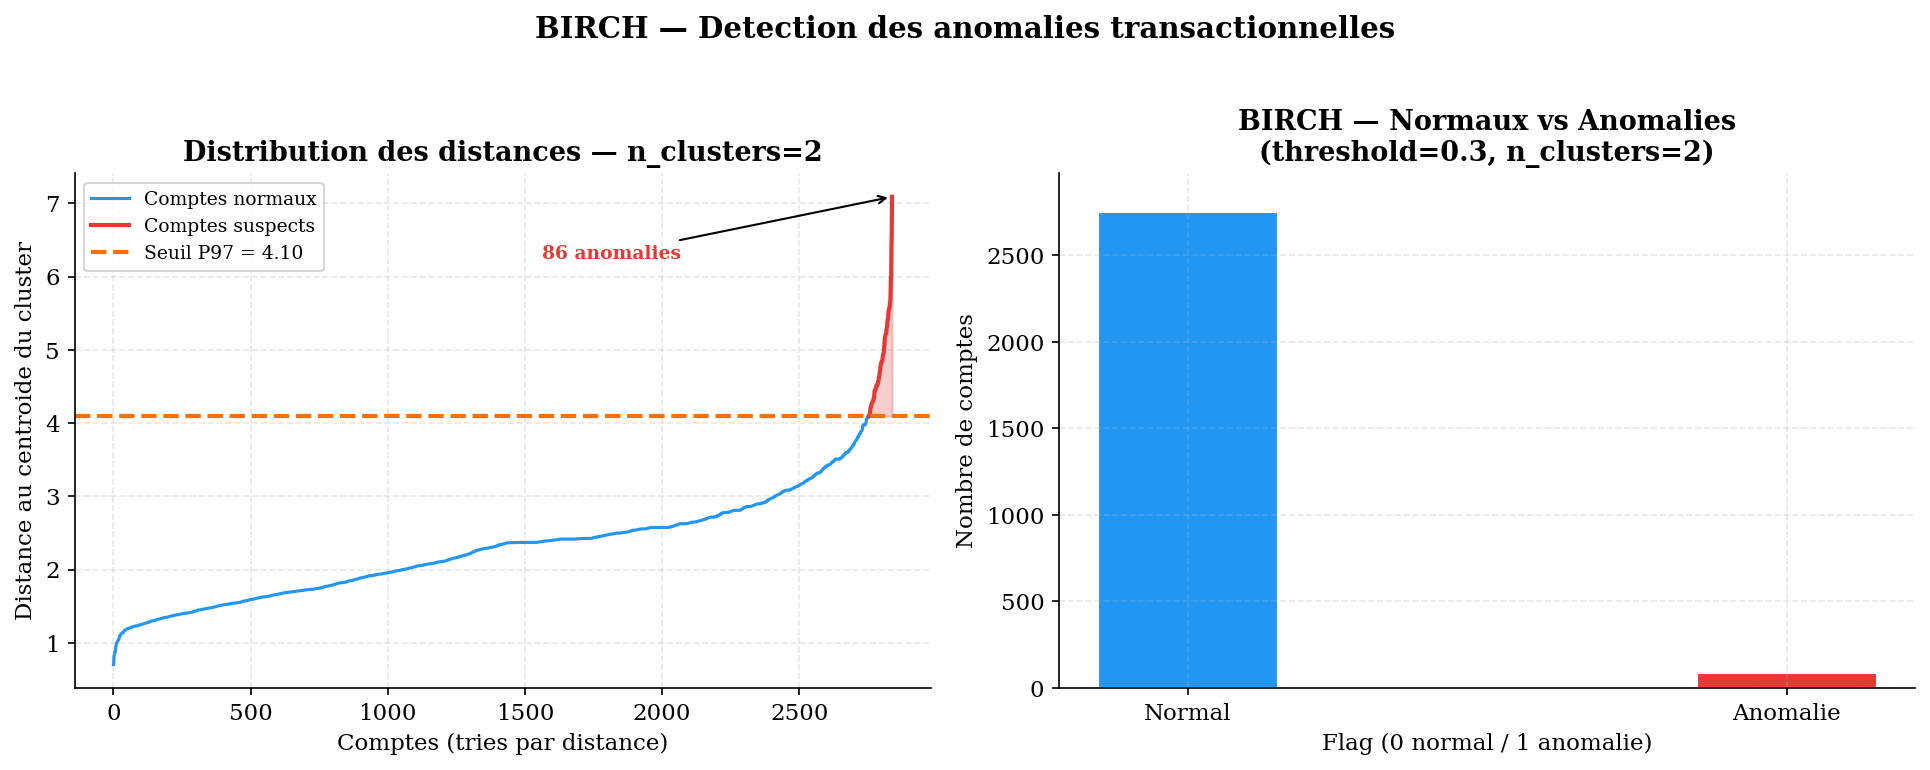

Figure sauvegardee : birch_rapport.png


In [15]:
# ============================================================
# DÉTECTION ANOMALIES BIRCH (seuil P97 sur distance au centroïde)
# ============================================================
# Calcul des centroïdes par cluster
centroids_birch = np.array([
    X_in_birch[clusters_birch == c].mean(axis=0)
    for c in np.unique(clusters_birch)
])

distances_birch = np.linalg.norm(
    X_in_birch - centroids_birch[clusters_birch], axis=1
)
threshold_birch  = np.percentile(distances_birch, 97)
df['cluster_birch']  = clusters_birch
df['distance_birch'] = distances_birch
df['birch_flag']     = (distances_birch > threshold_birch).astype(int)
nb_anomalies_birch   = df['birch_flag'].sum()
print(f"Anomalies BIRCH (P97) : {nb_anomalies_birch}")

anomaly_mask_birch = df['birch_flag'] == 1
normal_mask_birch  = df['birch_flag'] == 0

# ============================================================
# VISUALISATION BIRCH
# Panneau gauche : distances triées | Panneau droit : barres
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BIRCH — Detection des anomalies transactionnelles',
             fontsize=14, fontweight='bold', y=1.02)

# Panneau gauche : distances triées
ax = axes[0]
sorted_db  = np.sort(distances_birch)
idx_seuil  = np.searchsorted(sorted_db, threshold_birch)
ax.plot(range(idx_seuil), sorted_db[:idx_seuil],
        color=COL_NORMAL, linewidth=1.5, label='Comptes normaux')
ax.plot(range(idx_seuil, len(sorted_db)), sorted_db[idx_seuil:],
        color=COL_ANOMALY, linewidth=2, label='Comptes suspects')
ax.axhline(threshold_birch, color=COL_SEUIL, linestyle='--', linewidth=2,
           label=f'Seuil P97 = {threshold_birch:.2f}')
ax.fill_between(range(idx_seuil, len(sorted_db)), sorted_db[idx_seuil:],
                threshold_birch, alpha=0.25, color=COL_ANOMALY)
ax.set_xlabel('Comptes (tries par distance)')
ax.set_ylabel('Distance au centroide du cluster')
ax.set_title(f'Distribution des distances — n_clusters={nclust_birch}')
ax.legend(fontsize=9)
ax.annotate(f'{nb_anomalies_birch} anomalies',
            xy=(len(sorted_db)-1, sorted_db[-1]),
            xytext=(len(sorted_db)*0.55, sorted_db[-1]*0.88),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color=COL_ANOMALY, fontweight='bold')

# Panneau droit : diagramme barres
ax = axes[1]
ax.bar(['Normal', 'Anomalie'],
       [normal_mask_birch.sum(), anomaly_mask_birch.sum()],
       color=[COL_NORMAL, COL_ANOMALY], edgecolor='white', width=0.3)
ax.set_xlabel('Flag (0 normal / 1 anomalie)')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'BIRCH — Normaux vs Anomalies\n(threshold={thresh_birch}, n_clusters={nclust_birch})')
ax.set_ylim(0, normal_mask_birch.sum() * 1.08)

plt.tight_layout()
plt.savefig('birch_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : birch_rapport.png')

In [16]:
print('=' * 65)
print('ISOLATION FOREST — RECHERCHE DES MEILLEURS PARAMETRES (sans PCA)')
print('=' * 65)

contaminations_if = [0.01, 0.02, 0.03, 0.05]

print(f"\n{'VT':>4} | {'Contam':>6} | {'Feats':>5} | {'Anomalies':>9} | {'Silhouette':>10} | {'DB':>8} | {'CH':>8}")
print('-' * 65)

resultats_if = []
for vt in VT_THRESHOLDS:
    X_filtered, cols_final = apply_vt_and_corr_filter(X, vt, CORR_THRESHOLD)
    X_scaled = StandardScaler().fit_transform(X_filtered)
    for contam in contaminations_if:
        iso       = IsolationForest(n_estimators=300, contamination=contam, random_state=42, n_jobs=-1)
        labels_if = iso.fit_predict(X_scaled)
        scores_if = iso.decision_function(X_scaled)
        flags_if  = (labels_if == -1).astype(int)
        nb_an_if  = flags_if.sum()
        sil = silhouette_score(X_scaled, flags_if)
        db  = davies_bouldin_score(X_scaled, flags_if)
        ch  = calinski_harabasz_score(X_scaled, flags_if)
        resultats_if.append((vt, contam, len(cols_final), nb_an_if, sil, db, ch, X_scaled, labels_if, scores_if))
        print(f"{vt:>4.1f} | {contam:>6.2f} | {len(cols_final):>5} | {nb_an_if:>9} | {sil:>10.4f} | {db:>8.4f} | {ch:>8.1f}")

best_if = max(resultats_if, key=lambda r: r[4])
vt_if, contam_if, nfeat_if, nb_anomalies_if, sil_if, db_if, ch_if, X_in_if, labels_if, scores_if = best_if
print(f"\nMeilleure config IF : VT={vt_if}, contamination={contam_if}, {nfeat_if} features")
print(f"  Silhouette={sil_if:.4f} | DB={db_if:.4f} | CH={ch_if:.1f} | Anomalies={nb_anomalies_if}")

ISOLATION FOREST — RECHERCHE DES MEILLEURS PARAMETRES (sans PCA)

  VT | Contam | Feats | Anomalies | Silhouette |       DB |       CH
-----------------------------------------------------------------
 0.1 |   0.01 |    14 |        29 |     0.3689 |   1.5488 |     59.4
 0.1 |   0.02 |    14 |        57 |     0.3401 |   1.7382 |     93.0
 0.1 |   0.03 |    14 |        86 |     0.3233 |   1.8996 |    117.5
 0.1 |   0.05 |    14 |       142 |     0.3082 |   2.0837 |    160.7
 0.2 |   0.01 |    10 |        29 |     0.3832 |   1.5603 |     60.5
 0.2 |   0.02 |    10 |        57 |     0.3681 |   1.8178 |     93.8
 0.2 |   0.03 |    10 |        86 |     0.3488 |   2.0680 |    109.8
 0.2 |   0.05 |    10 |       142 |     0.3521 |   2.1422 |    168.9
 0.5 |   0.01 |     7 |        29 |     0.4826 |   1.3833 |     89.5
 0.5 |   0.02 |     7 |        57 |     0.4533 |   1.5477 |    140.4
 0.5 |   0.03 |     7 |        86 |     0.4348 |   1.7848 |    163.5
 0.5 |   0.05 |     7 |       142 |     

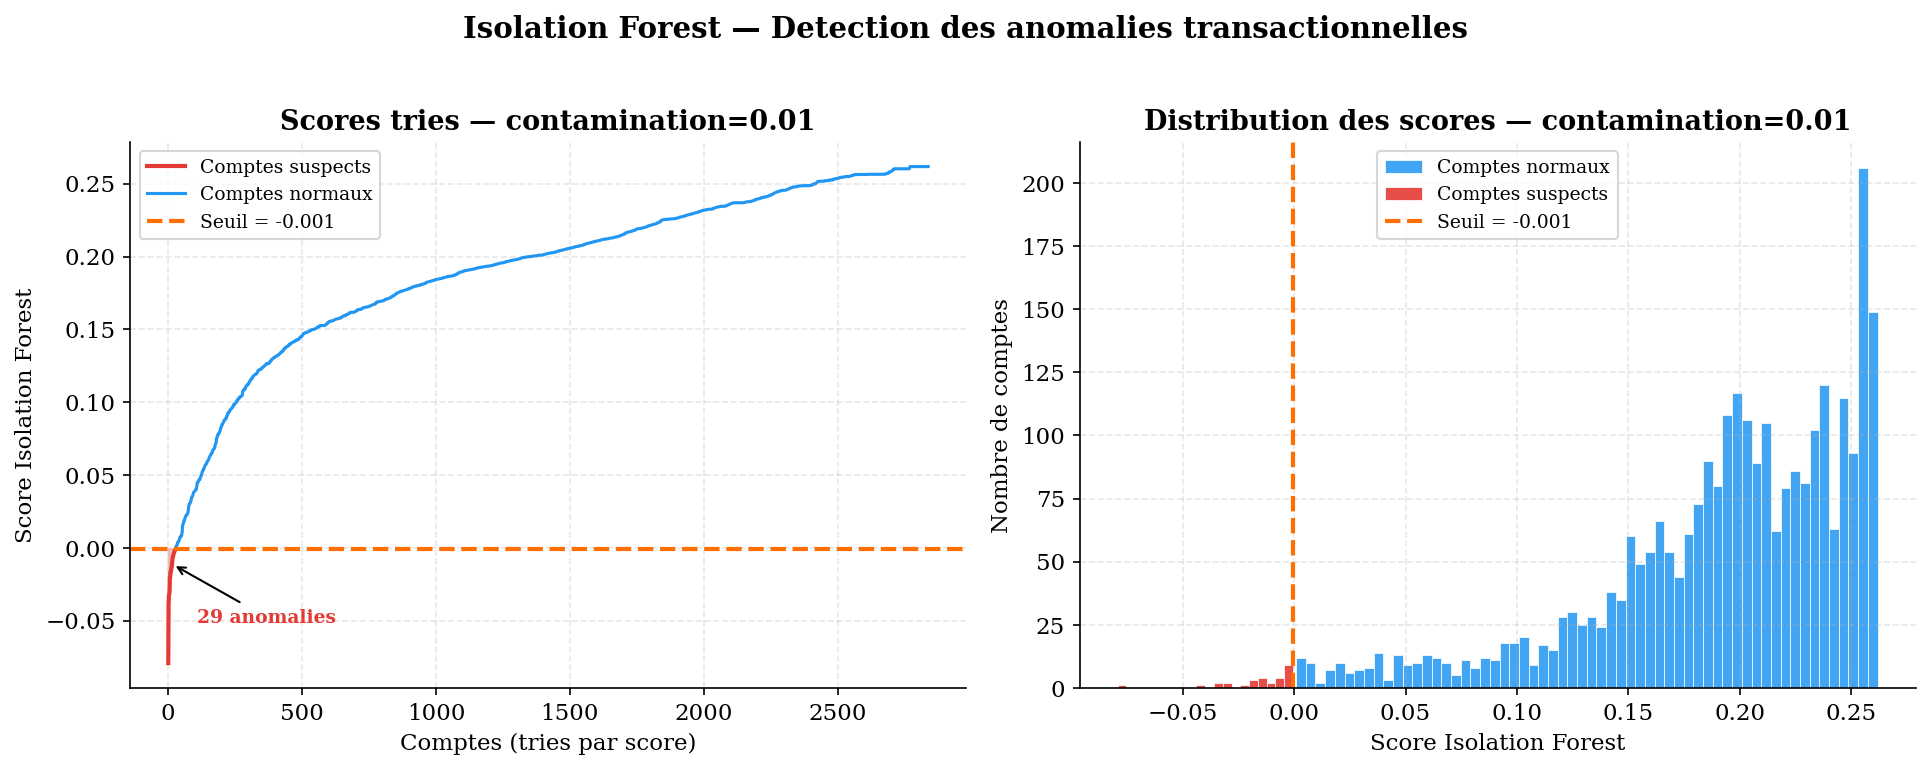

Figure sauvegardee : isolation_forest_rapport.png


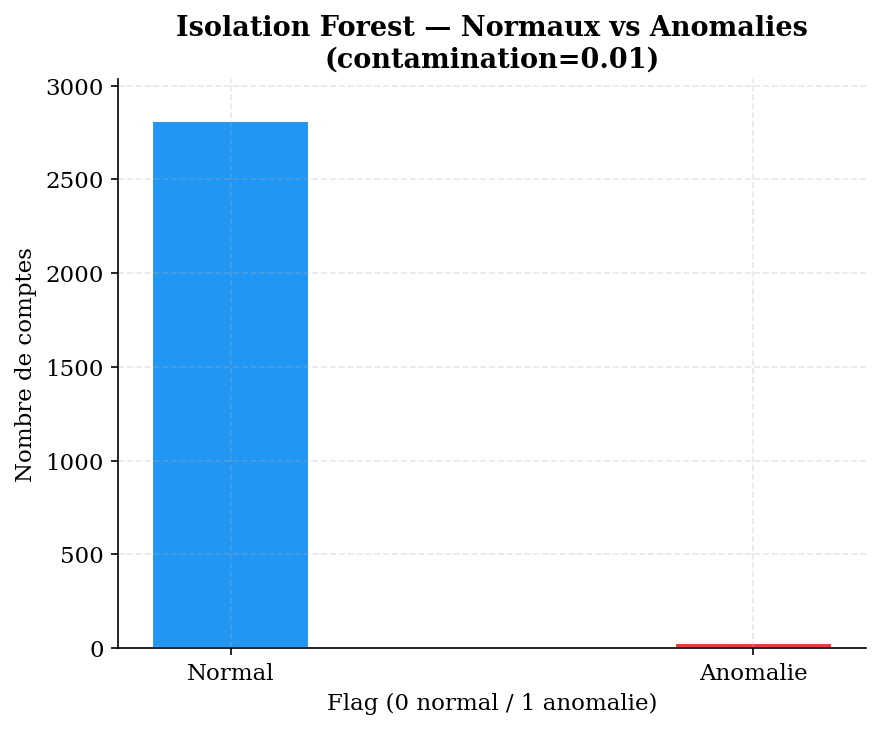

Figure sauvegardee : if_barres_rapport.png


In [17]:
# ============================================================
# VISUALISATION ISOLATION FOREST
# Panneau gauche : scores triés | Panneau droit : histogramme
# ============================================================
normal_mask_if  = labels_if == 1
anomaly_mask_if = labels_if == -1
threshold_if    = scores_if[labels_if == -1].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Isolation Forest — Detection des anomalies transactionnelles',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
sorted_s  = np.sort(scores_if)
idx_seuil = np.searchsorted(sorted_s, threshold_if)
ax.plot(range(idx_seuil), sorted_s[:idx_seuil], color=COL_ANOMALY, linewidth=2, label='Comptes suspects')
ax.plot(range(idx_seuil, len(sorted_s)), sorted_s[idx_seuil:], color=COL_NORMAL, linewidth=1.5, label='Comptes normaux')
ax.axhline(threshold_if, color=COL_SEUIL, linestyle='--', linewidth=2, label=f'Seuil = {threshold_if:.3f}')
ax.fill_between(range(idx_seuil), sorted_s[:idx_seuil], threshold_if, alpha=0.25, color=COL_ANOMALY)
ax.set_xlabel('Comptes (tries par score)')
ax.set_ylabel('Score Isolation Forest')
ax.set_title(f'Scores tries — contamination={contam_if}')
ax.legend(fontsize=9)
ax.annotate(f'{nb_anomalies_if} anomalies',
            xy=(idx_seuil//2, sorted_s[idx_seuil//2]),
            xytext=(idx_seuil + 80, sorted_s[idx_seuil//2] - 0.04),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color=COL_ANOMALY, fontweight='bold')

ax = axes[1]
ax.hist(scores_if[normal_mask_if], bins=60, alpha=0.85,
        color=COL_NORMAL, edgecolor='white', linewidth=0.4, label='Comptes normaux')
ax.hist(scores_if[anomaly_mask_if], bins=20, alpha=0.9,
        color=COL_ANOMALY, edgecolor='white', linewidth=0.4, label='Comptes suspects')
ax.axvline(threshold_if, color=COL_SEUIL, linestyle='--', linewidth=2, label=f'Seuil = {threshold_if:.3f}')
ax.set_xlabel('Score Isolation Forest')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'Distribution des scores — contamination={contam_if}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('isolation_forest_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : isolation_forest_rapport.png')

# Diagramme barres IF
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Normal', 'Anomalie'],
       [normal_mask_if.sum(), anomaly_mask_if.sum()],
       color=[COL_NORMAL, COL_ANOMALY], edgecolor='white', width=0.3)
ax.set_xlabel('Flag (0 normal / 1 anomalie)')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'Isolation Forest — Normaux vs Anomalies\n(contamination={contam_if})')
ax.set_ylim(0, normal_mask_if.sum() * 1.08)
plt.tight_layout()
plt.savefig('if_barres_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : if_barres_rapport.png')

## 4. Local Outlier Factor — LOF (avec PCA)
### Justification : LOF basé sur distances locales — sensible à la dimensionnalité

In [18]:
print('=' * 65)
print('LOF — RECHERCHE DES MEILLEURS PARAMETRES (avec PCA)')
print('=' * 65)

pca_components_lof = [2, 3, 5, None]
n_neighbors_list   = [10, 20, 30]
contaminations_lof = [0.02, 0.03, 0.04]

print(f"\n{'VT':>4} | {'PCA':>4} | {'n_neigh':>7} | {'Contam':>6} | {'Feats':>5} | {'Anomalies':>9} | {'Silhouette':>10} | {'DB':>8} | {'CH':>8}")
print('-' * 85)

resultats_lof = []
for vt in VT_THRESHOLDS:
    X_filtered, cols_final = apply_vt_and_corr_filter(X, vt, CORR_THRESHOLD)
    X_scaled = StandardScaler().fit_transform(X_filtered)
    for n_pca in pca_components_lof:
        if n_pca is not None:
            n_pca_safe = min(n_pca, X_scaled.shape[1] - 1)
            if n_pca_safe < 2:
                continue
            pca       = PCA(n_components=n_pca_safe, random_state=42)
            X_in      = pca.fit_transform(X_scaled)
            pca_label = str(n_pca_safe)
        else:
            X_in      = X_scaled.copy()
            pca_label = 'Non'
        for n_neigh in n_neighbors_list:
            for contam in contaminations_lof:
                lof        = LocalOutlierFactor(n_neighbors=n_neigh, contamination=contam)
                labels_lof = lof.fit_predict(X_in)
                scores_lof = lof.negative_outlier_factor_
                flags_lof  = (labels_lof == -1).astype(int)
                nb_an_lof  = flags_lof.sum()
                sil = silhouette_score(X_in, flags_lof)
                db  = davies_bouldin_score(X_in, flags_lof)
                ch  = calinski_harabasz_score(X_in, flags_lof)
                resultats_lof.append((vt, n_pca_safe if n_pca else None, n_neigh, contam,
                                       len(cols_final), nb_an_lof, sil, db, ch, X_in, labels_lof, scores_lof))
                print(f"{vt:>4.1f} | {pca_label:>4} | {n_neigh:>7} | {contam:>6.2f} | "
                      f"{len(cols_final):>5} | {nb_an_lof:>9} | {sil:>10.4f} | {db:>8.4f} | {ch:>8.1f}")

best_lof = max(resultats_lof, key=lambda r: r[6])
vt_lof, pca_lof, nneigh_lof, contam_lof, nfeat_lof, nb_anomalies_lof, \
    sil_lof, db_lof, ch_lof, X_in_lof, labels_lof, scores_lof = best_lof
pca_lof_label = str(pca_lof) if pca_lof else 'Non'
print(f"\nMeilleure config : VT={vt_lof}, PCA={pca_lof_label}, n_neighbors={nneigh_lof}, contamination={contam_lof}")
print(f"  Silhouette={sil_lof:.4f} | DB={db_lof:.4f} | CH={ch_lof:.1f} | Anomalies={nb_anomalies_lof}")

LOF — RECHERCHE DES MEILLEURS PARAMETRES (avec PCA)

  VT |  PCA | n_neigh | Contam | Feats | Anomalies | Silhouette |       DB |       CH
-------------------------------------------------------------------------------------
 0.1 |    2 |      10 |   0.02 |    14 |        55 |     0.0091 |   0.9213 |     77.7
 0.1 |    2 |      10 |   0.03 |    14 |        86 |     0.0509 |   1.0256 |    117.7
 0.1 |    2 |      10 |   0.04 |    14 |       114 |     0.0907 |   1.6515 |     99.9
 0.1 |    2 |      20 |   0.02 |    14 |        57 |     0.0996 |   2.0204 |     39.6
 0.1 |    2 |      20 |   0.03 |    14 |        86 |     0.1247 |   3.5893 |     24.7
 0.1 |    2 |      20 |   0.04 |    14 |       112 |     0.1270 |   4.0630 |     25.7
 0.1 |    2 |      30 |   0.02 |    14 |        57 |     0.0729 |   1.2356 |     66.9
 0.1 |    2 |      30 |   0.03 |    14 |        86 |     0.1165 |   2.8237 |     36.3
 0.1 |    2 |      30 |   0.04 |    14 |       114 |     0.1633 |   6.1535 |     12.9
 

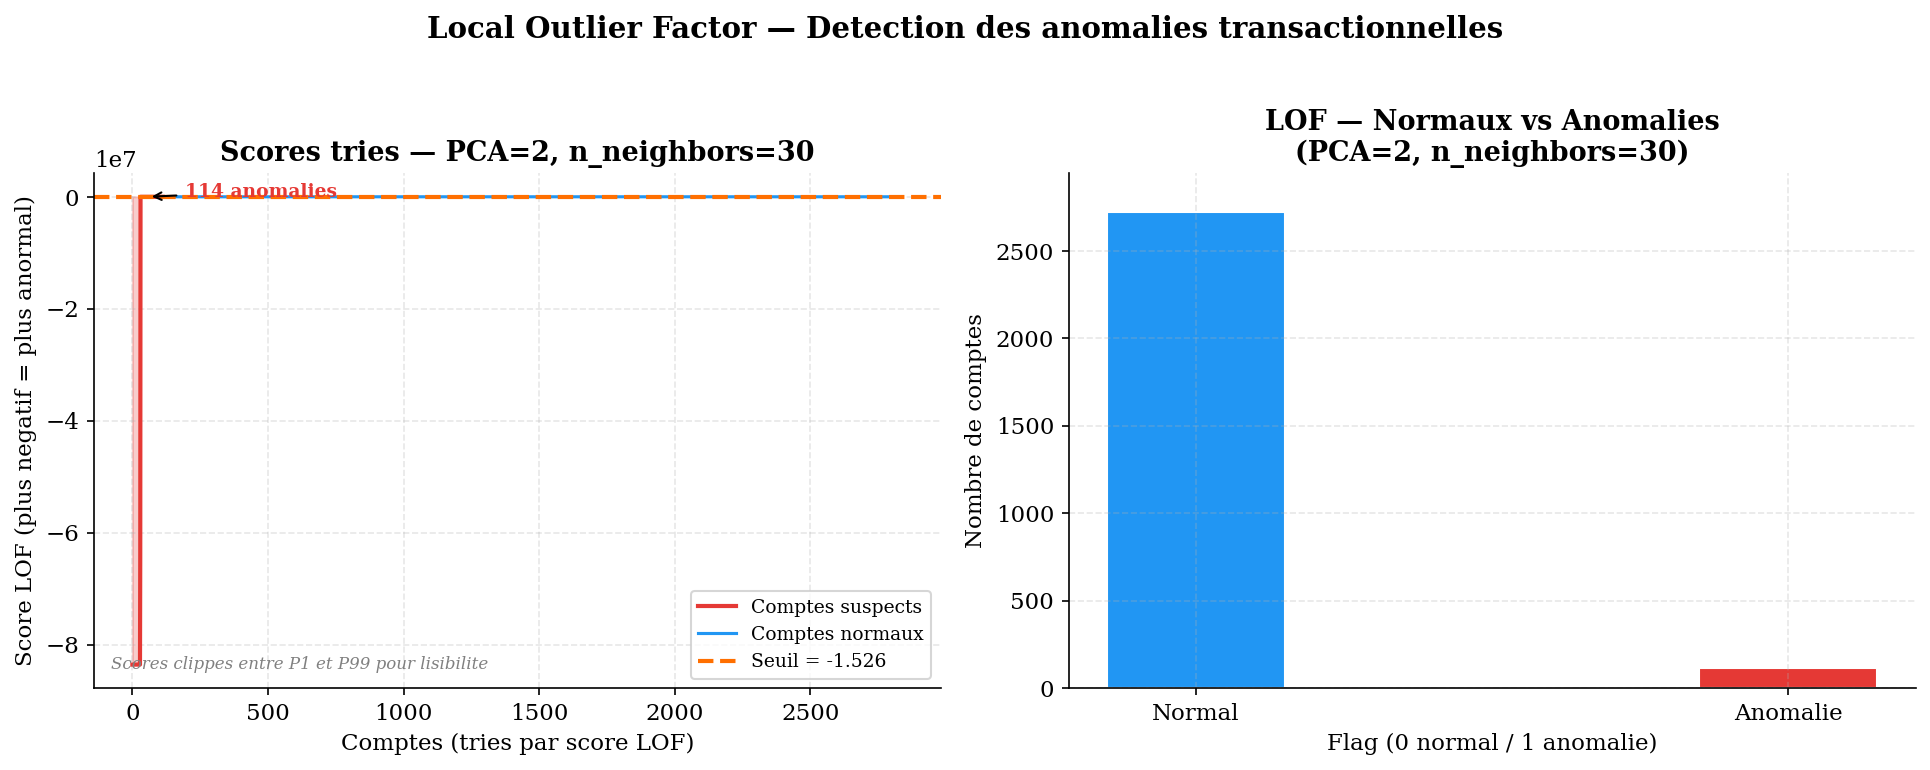

In [19]:
# ============================================================
# VISUALISATION LOF
# Panneau gauche : scores triés | Panneau droit : barres
# ============================================================
normal_mask_lof  = labels_lof == 1
anomaly_mask_lof = labels_lof == -1
threshold_lof    = scores_lof[labels_lof == -1].max()

# Clipping P1/P99 pour le panneau gauche (outliers extrêmes)
p1  = np.percentile(scores_lof, 1)
p99 = np.percentile(scores_lof, 99)
scores_clipped    = np.clip(scores_lof, p1, p99)
threshold_clipped = np.clip(threshold_lof, p1, p99)
note_clip = 'Scores clippes entre P1 et P99 pour lisibilite'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Local Outlier Factor — Detection des anomalies transactionnelles',
             fontsize=14, fontweight='bold', y=1.02)

# Panneau gauche : scores triés (clippés)
ax = axes[0]
sorted_sl = np.sort(scores_clipped)
idx_seuil = np.searchsorted(sorted_sl, threshold_clipped)
ax.plot(range(idx_seuil), sorted_sl[:idx_seuil], color=COL_ANOMALY, linewidth=2, label='Comptes suspects')
ax.plot(range(idx_seuil, len(sorted_sl)), sorted_sl[idx_seuil:], color=COL_NORMAL, linewidth=1.5, label='Comptes normaux')
ax.axhline(threshold_clipped, color=COL_SEUIL, linestyle='--', linewidth=2, label=f'Seuil = {threshold_lof:.3f}')
ax.fill_between(range(idx_seuil), sorted_sl[:idx_seuil], threshold_clipped, alpha=0.25, color=COL_ANOMALY)
ax.set_xlabel('Comptes (tries par score LOF)')
ax.set_ylabel('Score LOF (plus negatif = plus anormal)')
ax.set_title(f'Scores tries — PCA={pca_lof_label}, n_neighbors={nneigh_lof}')
ax.legend(fontsize=9)
ax.text(0.02, 0.03, note_clip, transform=ax.transAxes, fontsize=8, va='bottom', color='gray', style='italic')
ax.annotate(f'{nb_anomalies_lof} anomalies',
            xy=(idx_seuil//2, sorted_sl[max(0, idx_seuil//2)]),
            xytext=(idx_seuil + 80, sorted_sl[max(0, idx_seuil//2)] - 0.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color=COL_ANOMALY, fontweight='bold')

# Panneau droit : diagramme barres
ax = axes[1]
ax.bar(['Normal', 'Anomalie'],
       [normal_mask_lof.sum(), anomaly_mask_lof.sum()],
       color=[COL_NORMAL, COL_ANOMALY], edgecolor='white', width=0.3)
ax.set_xlabel('Flag (0 normal / 1 anomalie)')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'LOF — Normaux vs Anomalies\n(PCA={pca_lof_label}, n_neighbors={nneigh_lof})')
ax.set_ylim(0, normal_mask_lof.sum() * 1.08)

plt.tight_layout()
plt.savefig('lof_rapport.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. One-Class SVM (sans PCA)
### Justification : kernel RBF projette implicitement dans un espace de grande dimension — PCA redondante

In [20]:
print('=' * 65)
print('ONE-CLASS SVM — RECHERCHE DES MEILLEURS PARAMETRES (sans PCA)')
print('=' * 65)

nu_values = [0.01, 0.02, 0.03, 0.05]

print(f"\n{'VT':>4} | {'nu':>5} | {'Feats':>5} | {'Anomalies':>9} | {'Silhouette':>10} | {'DB':>8} | {'CH':>8}")
print('-' * 62)

resultats_svm = []
for vt in VT_THRESHOLDS:
    X_filtered, cols_final = apply_vt_and_corr_filter(X, vt, CORR_THRESHOLD)
    X_scaled = StandardScaler().fit_transform(X_filtered)
    for nu in nu_values:
        ocsvm      = OneClassSVM(kernel='rbf', nu=nu, gamma='scale', cache_size=1000)
        ocsvm.fit(X_scaled)
        preds_svm  = ocsvm.predict(X_scaled)
        scores_svm = ocsvm.decision_function(X_scaled)
        flags_svm  = (preds_svm == -1).astype(int)
        nb_an_svm  = flags_svm.sum()
        sil = silhouette_score(X_scaled, flags_svm)
        db  = davies_bouldin_score(X_scaled, flags_svm)
        ch  = calinski_harabasz_score(X_scaled, flags_svm)
        resultats_svm.append((vt, nu, len(cols_final), nb_an_svm, sil, db, ch, X_scaled, preds_svm, scores_svm))
        print(f"{vt:>4.1f} | {nu:>5.2f} | {len(cols_final):>5} | {nb_an_svm:>9} | {sil:>10.4f} | {db:>8.4f} | {ch:>8.1f}")

best_svm = max(resultats_svm, key=lambda r: r[4])
vt_svm, nu_svm, nfeat_svm, nb_anomalies_svm, sil_svm, db_svm, ch_svm, X_in_svm, preds_svm, scores_svm = best_svm
print(f"\nMeilleure config : VT={vt_svm}, nu={nu_svm}, {nfeat_svm} features")
print(f"  Silhouette={sil_svm:.4f} | DB={db_svm:.4f} | CH={ch_svm:.1f} | Anomalies={nb_anomalies_svm}")

ONE-CLASS SVM — RECHERCHE DES MEILLEURS PARAMETRES (sans PCA)

  VT |    nu | Feats | Anomalies | Silhouette |       DB |       CH
--------------------------------------------------------------
 0.1 |  0.01 |    14 |        51 |     0.2699 |   4.1152 |     17.4
 0.1 |  0.02 |    14 |        69 |     0.2518 |   5.0890 |     15.0
 0.1 |  0.03 |    14 |        87 |     0.2692 |   4.5059 |     24.7
 0.1 |  0.05 |    14 |       141 |     0.2592 |   4.0761 |     45.8
 0.2 |  0.01 |    10 |       182 |     0.0826 |   1.7656 |    123.7
 0.2 |  0.02 |    10 |        57 |     0.3369 |   2.9926 |     38.3
 0.2 |  0.03 |    10 |       103 |     0.2878 |   4.1601 |     34.1
 0.2 |  0.05 |    10 |       139 |     0.3005 |   3.4168 |     66.3
 0.5 |  0.01 |     7 |       136 |     0.0876 |   2.3446 |     66.1
 0.5 |  0.02 |     7 |       157 |     0.1767 |   2.7489 |     71.8
 0.5 |  0.03 |     7 |       167 |     0.2238 |   3.9301 |     48.1
 0.5 |  0.05 |     7 |       162 |     0.3217 |   4.3179 |

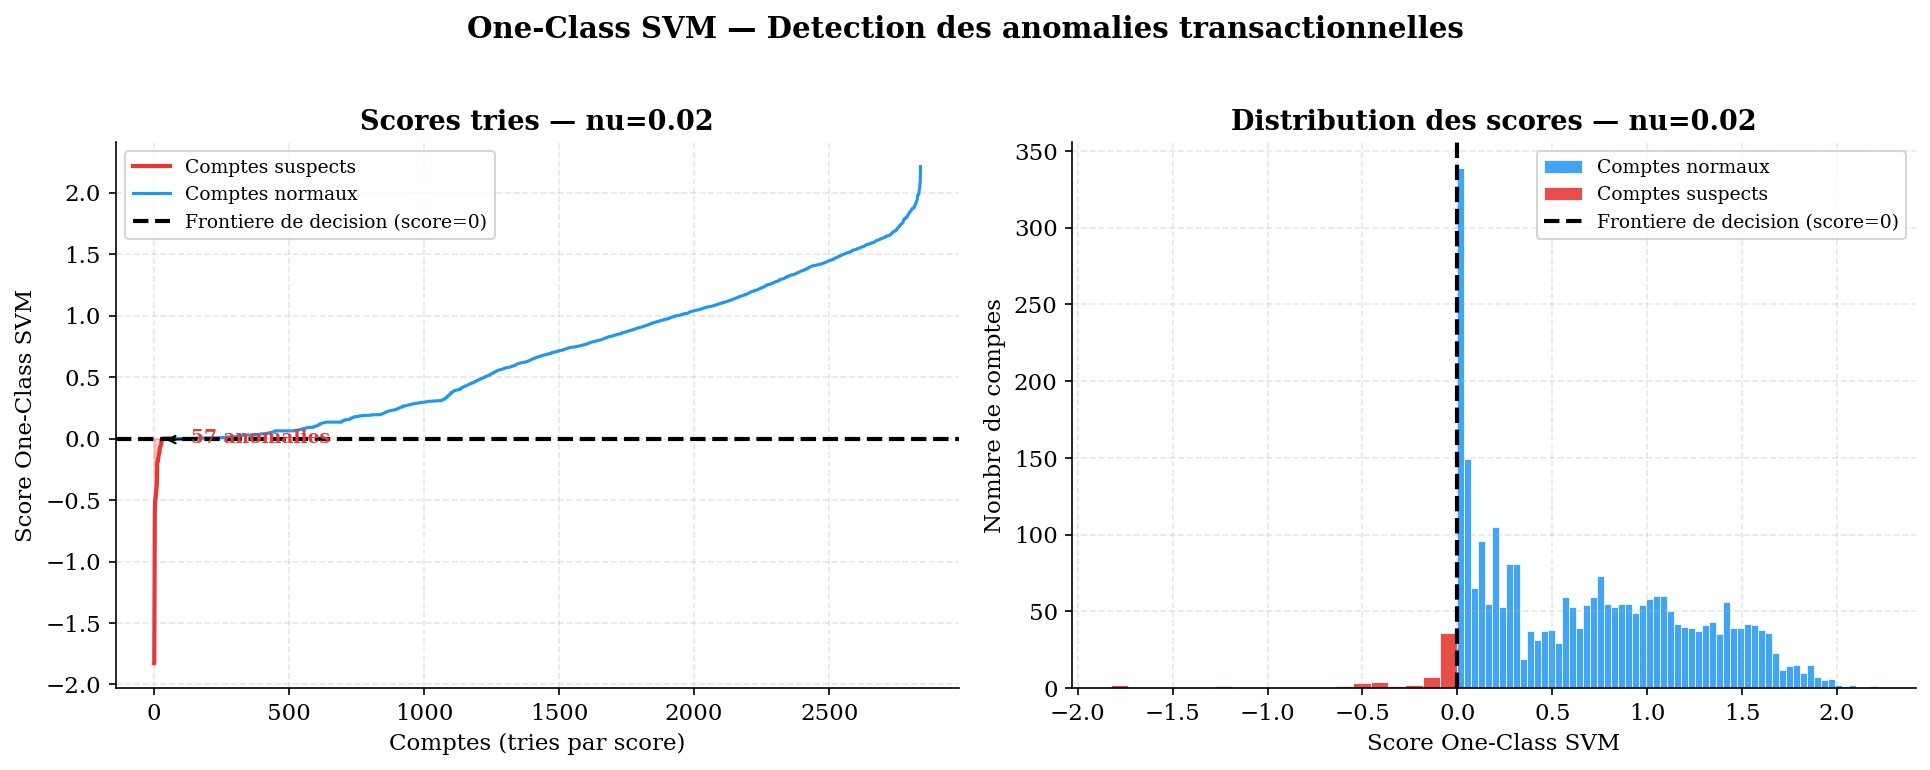

Figure sauvegardee : ocsvm_rapport.png


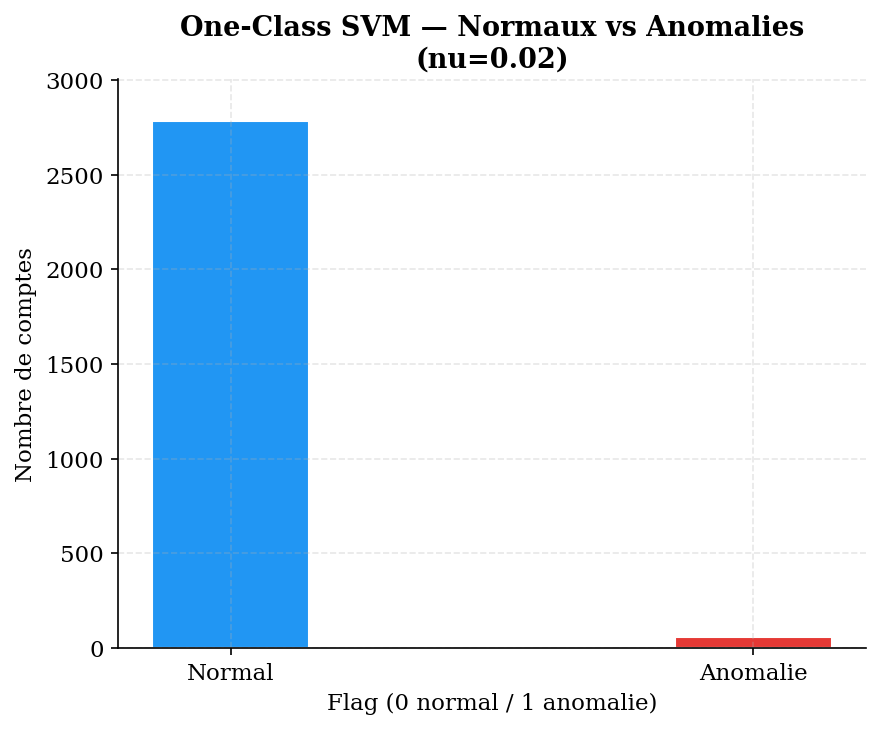

Figure sauvegardee : svm_barres_rapport.png


In [21]:
# ============================================================
# VISUALISATION ONE-CLASS SVM
# Panneau gauche : scores triés | Panneau droit : histogramme
# ============================================================
normal_mask_svm  = preds_svm == 1
anomaly_mask_svm = preds_svm == -1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('One-Class SVM — Detection des anomalies transactionnelles',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
sorted_sv = np.sort(scores_svm)
idx_seuil = np.searchsorted(sorted_sv, 0)
ax.plot(range(idx_seuil), sorted_sv[:idx_seuil], color=COL_ANOMALY, linewidth=2, label='Comptes suspects')
ax.plot(range(idx_seuil, len(sorted_sv)), sorted_sv[idx_seuil:], color=COL_NORMAL, linewidth=1.5, label='Comptes normaux')
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Frontiere de decision (score=0)')
ax.fill_between(range(idx_seuil), sorted_sv[:idx_seuil], 0, alpha=0.25, color=COL_ANOMALY)
ax.set_xlabel('Comptes (tries par score)')
ax.set_ylabel('Score One-Class SVM')
ax.set_title(f'Scores tries — nu={nu_svm}')
ax.legend(fontsize=9)
ax.annotate(f'{nb_anomalies_svm} anomalies',
            xy=(idx_seuil//2, sorted_sv[idx_seuil//2]),
            xytext=(idx_seuil + 80, sorted_sv[idx_seuil//2] - 0.02),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color=COL_ANOMALY, fontweight='bold')

ax = axes[1]
ax.hist(scores_svm[normal_mask_svm], bins=60, alpha=0.85,
        color=COL_NORMAL, edgecolor='white', linewidth=0.4, label='Comptes normaux')
ax.hist(scores_svm[anomaly_mask_svm], bins=20, alpha=0.9,
        color=COL_ANOMALY, edgecolor='white', linewidth=0.4, label='Comptes suspects')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Frontiere de decision (score=0)')
ax.set_xlabel('Score One-Class SVM')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'Distribution des scores — nu={nu_svm}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ocsvm_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : ocsvm_rapport.png')

# Diagramme barres SVM
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Normal', 'Anomalie'],
       [normal_mask_svm.sum(), anomaly_mask_svm.sum()],
       color=[COL_NORMAL, COL_ANOMALY], edgecolor='white', width=0.3)
ax.set_xlabel('Flag (0 normal / 1 anomalie)')
ax.set_ylabel('Nombre de comptes')
ax.set_title(f'One-Class SVM — Normaux vs Anomalies\n(nu={nu_svm})')
ax.set_ylim(0, normal_mask_svm.sum() * 1.08)
plt.tight_layout()
plt.savefig('svm_barres_rapport.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : svm_barres_rapport.png')

## 6. Comparaison finale & Score composite

In [22]:
print('\n' + '=' * 80)
print('COMPARAISON FINALE DES MODELES NON SUPERVISES')
print('=' * 80)

comparison = pd.DataFrame([
    {'Modele': 'K-Means',         'VT': vt_km,  'PCA': pca_km_label,
     'Nb Features': nfeat_km,  'Nb Anomalies': nb_anomalies_km,
     'Silhouette': round(sil_km, 4), 'Davies-Bouldin': round(db_km, 4), 'Calinski-Harabasz': round(ch_km, 1)},
    {'Modele': 'BIRCH',           'VT': vt_birch, 'PCA': 'Non',
     'Nb Features': nfeat_birch, 'Nb Anomalies': nb_anomalies_birch,
     'Silhouette': round(sil_birch, 4), 'Davies-Bouldin': round(db_birch, 4), 'Calinski-Harabasz': round(ch_birch, 1)},
    {'Modele': 'Isolation Forest', 'VT': vt_if,  'PCA': 'Non',
     'Nb Features': nfeat_if,  'Nb Anomalies': nb_anomalies_if,
     'Silhouette': round(sil_if, 4), 'Davies-Bouldin': round(db_if, 4), 'Calinski-Harabasz': round(ch_if, 1)},
    {'Modele': 'LOF',              'VT': vt_lof, 'PCA': pca_lof_label,
     'Nb Features': nfeat_lof, 'Nb Anomalies': nb_anomalies_lof,
     'Silhouette': round(sil_lof, 4), 'Davies-Bouldin': round(db_lof, 4), 'Calinski-Harabasz': round(ch_lof, 1)},
    {'Modele': 'One-Class SVM',    'VT': vt_svm, 'PCA': 'Non',
     'Nb Features': nfeat_svm, 'Nb Anomalies': nb_anomalies_svm,
     'Silhouette': round(sil_svm, 4), 'Davies-Bouldin': round(db_svm, 4), 'Calinski-Harabasz': round(ch_svm, 1)},
]).sort_values('Silhouette', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))


COMPARAISON FINALE DES MODELES NON SUPERVISES
          Modele  VT PCA  Nb Features  Nb Anomalies  Silhouette  Davies-Bouldin  Calinski-Harabasz
         K-Means 0.1   2           14            86      0.5307          0.6926             4865.7
           BIRCH 0.5 Non            7            86      0.5035          0.7915              459.1
Isolation Forest 0.5 Non            7            29      0.4826          1.3833               89.5
   One-Class SVM 0.2 Non           10            57      0.3369          2.9926               38.3
             LOF 0.1   2           14           114      0.1633          6.1535               12.9


In [23]:
# ============================================================
# SCORE COMPOSITE NON SUPERVISÉ
# Basé sur une normalisation mathématique intrinsèque
# sans coefficients arbitraires — poids égaux 1/3 chacun
#
# Formule :
# Score = 1/3 × (Sil+1)/2  +  1/3 × CH/(1+CH)  +  1/3 × 1/(1+DB)
#
# Justification des normalisations :
# - (Sil+1)/2      : Silhouette ∈ [-1,1] → ramené à [0,1]
# - CH/(1+CH)      : CH ∈ [0,+∞) → ramené à [0,1] via transformation sigmoïde
# - 1/(1+DB)       : DB ∈ [0,+∞), plus faible = meilleur → inversé et ramené à [0,1]
# ============================================================

df_score = comparison.copy()

df_score['Sil_norm'] = (df_score['Silhouette'] + 1) / 2
df_score['CH_norm']  = df_score['Calinski-Harabasz'] / (1 + df_score['Calinski-Harabasz'])
df_score['DB_norm']  = 1 / (1 + df_score['Davies-Bouldin'])

df_score['Score Composite'] = (
    (1/3) * df_score['Sil_norm'] +
    (1/3) * df_score['CH_norm']  +
    (1/3) * df_score['DB_norm']
).round(4)

df_score = df_score.sort_values('Score Composite', ascending=False).reset_index(drop=True)
df_score.index += 1

print('\n' + '=' * 65)
print('SCORE COMPOSITE — SELECTION DU MEILLEUR MODELE')
print('=' * 65)
print(df_score[['Modele', 'Silhouette', 'Davies-Bouldin',
                'Calinski-Harabasz', 'Score Composite']].to_string())
print(f"\nMeilleur modele : {df_score.iloc[0]['Modele']}")
print(f"Score           : {df_score.iloc[0]['Score Composite']:.4f}")


SCORE COMPOSITE — SELECTION DU MEILLEUR MODELE
             Modele  Silhouette  Davies-Bouldin  Calinski-Harabasz  Score Composite
1           K-Means      0.5307          0.6926             4865.7           0.7853
2             BIRCH      0.5035          0.7915              459.1           0.7693
3  Isolation Forest      0.4826          1.3833               89.5           0.7166
4     One-Class SVM      0.3369          2.9926               38.3           0.6312
5               LOF      0.1633          6.1535               12.9           0.5498

Meilleur modele : K-Means
Score           : 0.7853


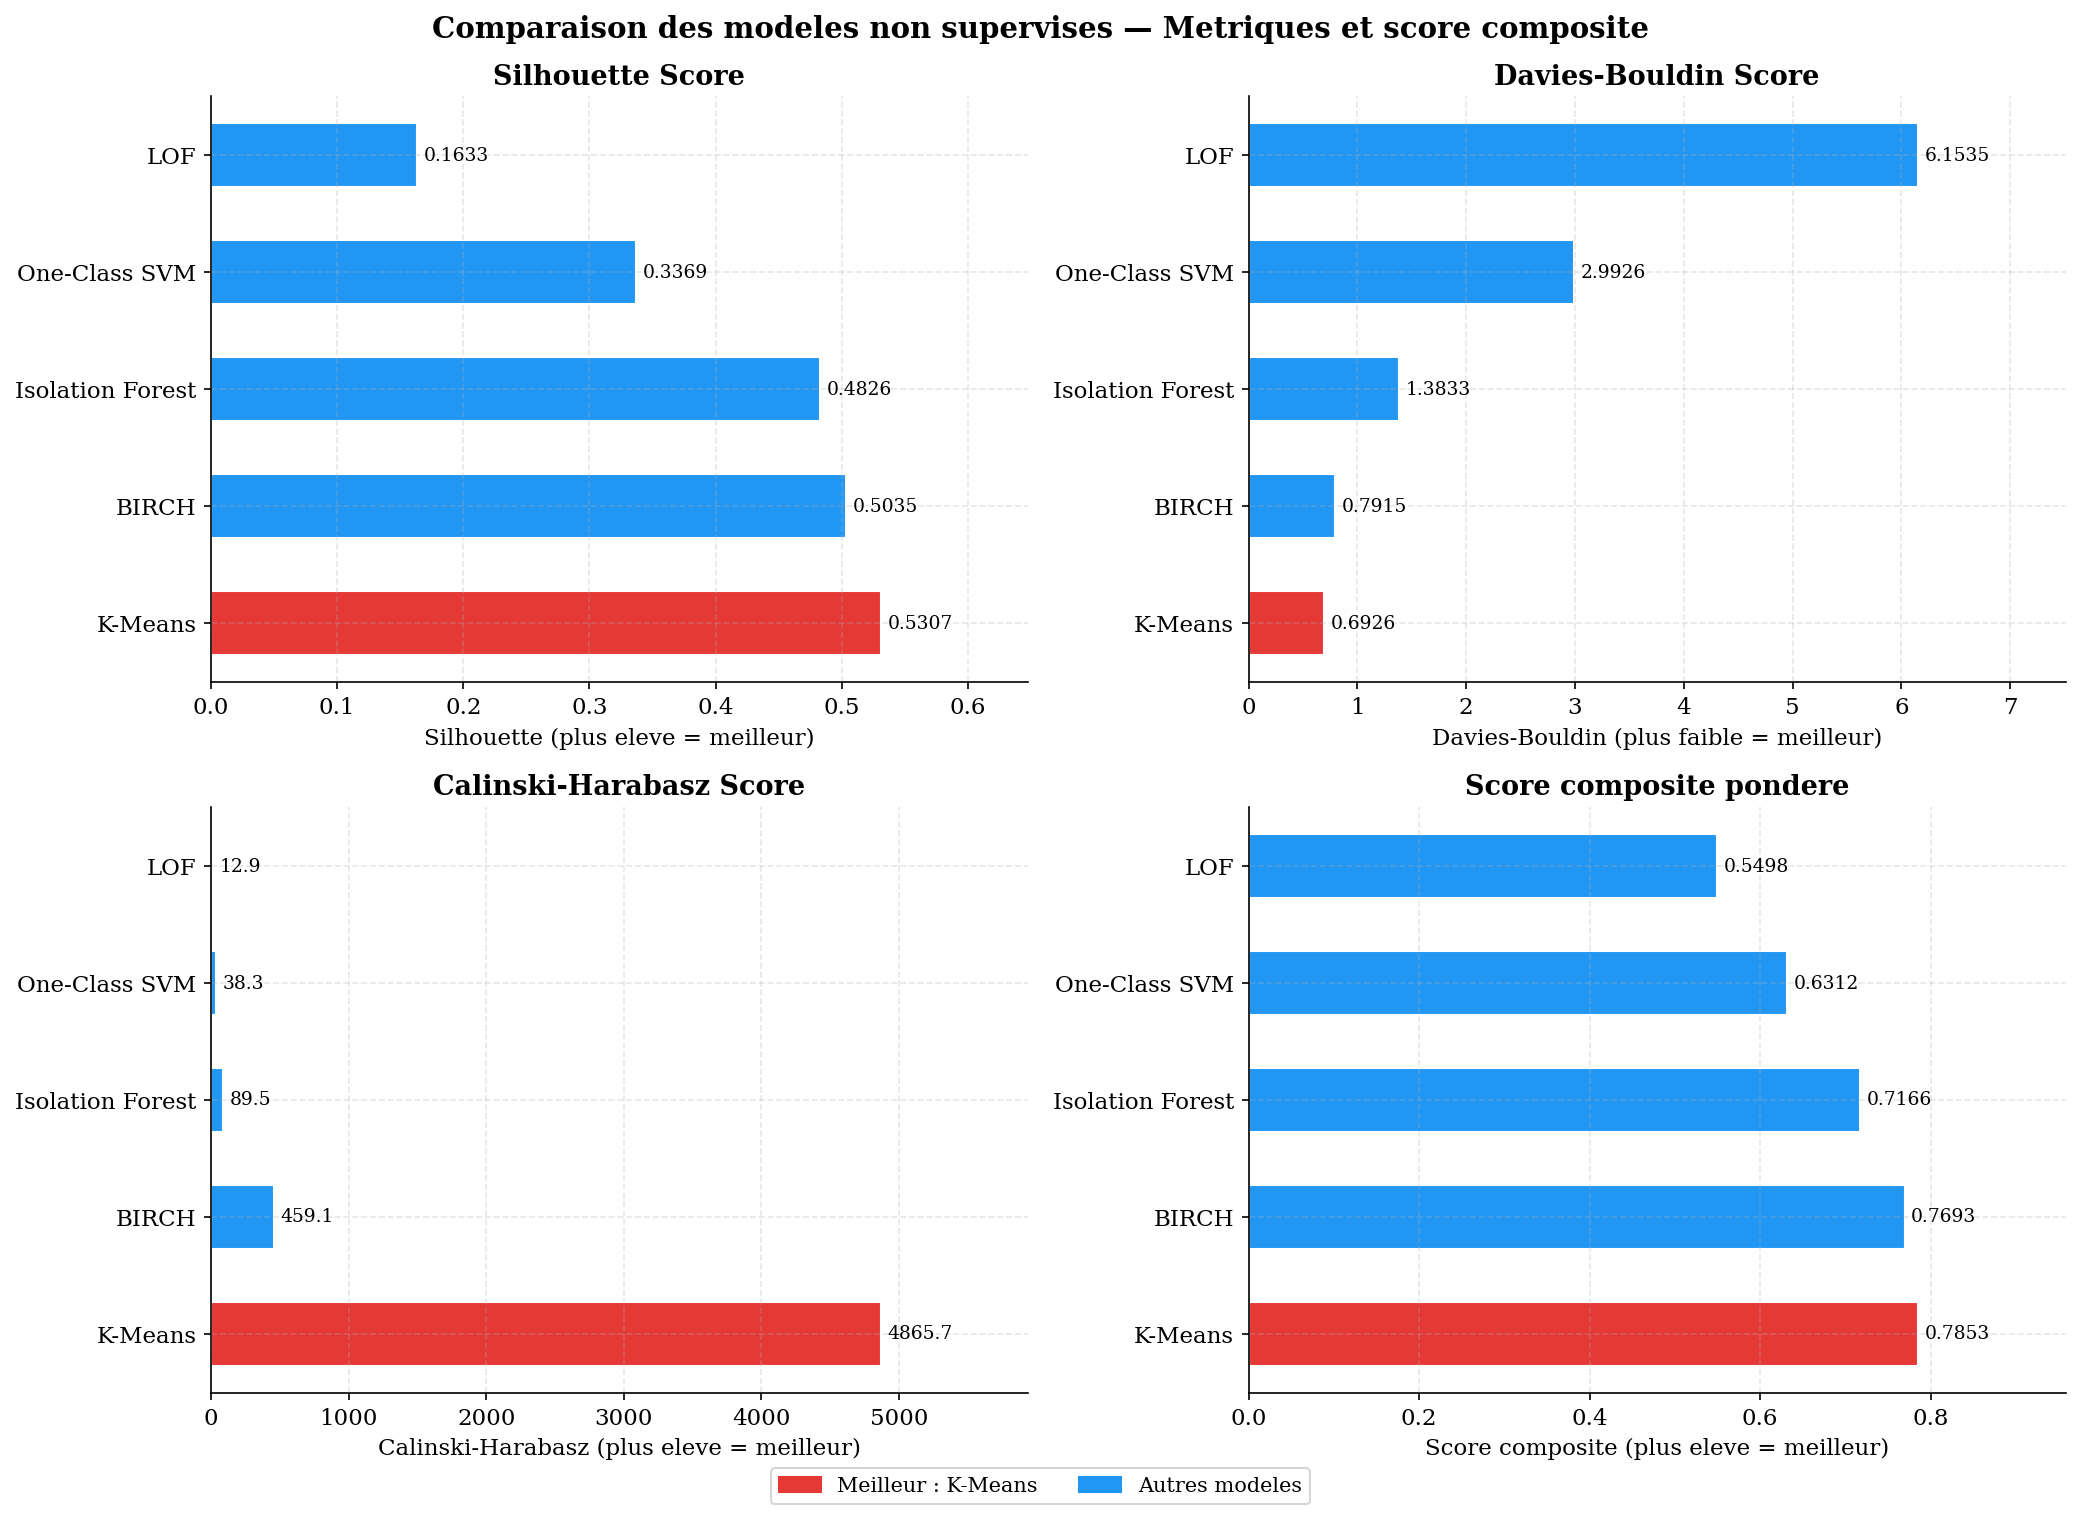

In [24]:
# ============================================================
# VISUALISATION COMPARATIVE FINALE
# ============================================================
modeles  = df_score['Modele'].tolist()
sil_vals = df_score['Silhouette'].tolist()
db_vals  = df_score['Davies-Bouldin'].tolist()
ch_vals  = df_score['Calinski-Harabasz'].tolist()
sc_vals  = df_score['Score Composite'].tolist()

meilleur    = df_score.iloc[0]['Modele']
colors_best = [COL_ANOMALY if m == meilleur else COL_NORMAL for m in modeles]
colors_db   = [COL_ANOMALY if v == min(db_vals) else COL_NORMAL for v in db_vals]
colors_ch   = [COL_ANOMALY if v == max(ch_vals) else COL_NORMAL for v in ch_vals]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparaison des modeles non supervises — Metriques et score composite',
             fontsize=14, fontweight='bold')

def barh_panel(ax, vals, colors, xlabel, title, fmt='{:.4f}'):
    bars = ax.barh(modeles, vals, color=colors, edgecolor='white', height=0.55)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xlim(0, max(vals) * 1.22)
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                fmt.format(v), va='center', fontsize=9)

barh_panel(axes[0,0], sil_vals, colors_best, 'Silhouette (plus eleve = meilleur)', 'Silhouette Score')
barh_panel(axes[0,1], db_vals,  colors_db,   'Davies-Bouldin (plus faible = meilleur)', 'Davies-Bouldin Score')
barh_panel(axes[1,0], ch_vals,  colors_ch,   'Calinski-Harabasz (plus eleve = meilleur)', 'Calinski-Harabasz Score', fmt='{:.1f}')
barh_panel(axes[1,1], sc_vals,  colors_best, 'Score composite (plus eleve = meilleur)', 'Score composite pondere')

legend_patches = [
    mpatches.Patch(color=COL_ANOMALY, label=f'Meilleur : {meilleur}'),
    mpatches.Patch(color=COL_NORMAL,  label='Autres modeles')
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('comparaison_nonsupervises_rapport.png', dpi=300, bbox_inches='tight')
plt.show()